# 简单神经网络

## torch包测试

In [5]:
import torch
import torchvision
print('✅ PyTorch 版本:', torch.__version__)
print('✅ torchvision 版本:', torchvision.__version__)
print('✅ CUDA 是否可用:', torch.cuda.is_available())
print('✅ CPU 模式正常工作')

✅ PyTorch 版本: 2.2.2
✅ torchvision 版本: 0.17.2
✅ CUDA 是否可用: False
✅ CPU 模式正常工作


## 简单的线性回归神经网络

In [2]:
import torch.nn as nn
import torch.optim as optim

# 创建一个简单的线性回归神经网络
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(1, 1)  # 输入1维，输出1维
    
    def forward(self, x):
        return self.fc(x)

# 生成简单数据：y = 2x + 1
x = torch.tensor([[1.0], [2.0], [3.0], [4.0]])
y = torch.tensor([[3.0], [5.0], [7.0], [9.0]])

# 训练模型
model = SimpleNet()
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

for epoch in range(100):
    optimizer.zero_grad()
    output = model(x)
    loss = criterion(output, y)
    loss.backward()
    optimizer.step()

# 测试：输入 x=5，期望输出 11
test_x = torch.tensor([[5.0]])
print(f"预测结果: {model(test_x).item():.2f} (期望: 11.00)")

预测结果: 11.18 (期望: 11.00)


## 使用多层神经网络对鸢尾花数据集进行分类

训练集大小: 105
测试集大小: 45
IrisClassifier(
  (layer1): Linear(in_features=4, out_features=10, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=10, out_features=3, bias=True)
)
Epoch [20/200], Loss: 0.4513, Train Acc: 0.8381
Epoch [40/200], Loss: 0.2732, Train Acc: 0.9048
Epoch [60/200], Loss: 0.1889, Train Acc: 0.9333
Epoch [80/200], Loss: 0.1232, Train Acc: 0.9714
Epoch [100/200], Loss: 0.0858, Train Acc: 0.9714
Epoch [120/200], Loss: 0.0656, Train Acc: 0.9714
Epoch [140/200], Loss: 0.0537, Train Acc: 0.9810
Epoch [160/200], Loss: 0.0457, Train Acc: 0.9905
Epoch [180/200], Loss: 0.0399, Train Acc: 0.9905
Epoch [200/200], Loss: 0.0356, Train Acc: 0.9905

✅ 测试集准确率: 0.9333 (42/45)


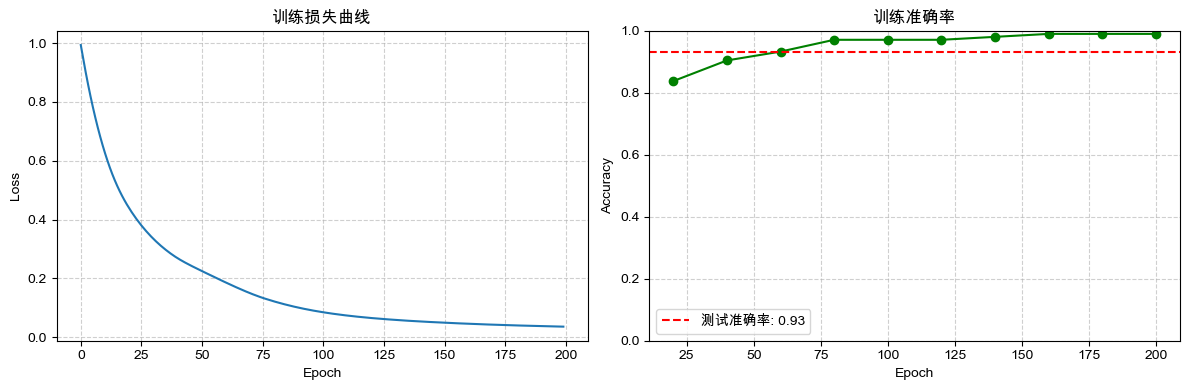


📊 预测示例（测试集前5个样本）:
--------------------------------------------------
样本 1: 预测类别 = 2 (virginica), 真实类别 = 2 (virginica)
样本 2: 预测类别 = 1 (versicolor), 真实类别 = 1 (versicolor)
样本 3: 预测类别 = 1 (versicolor), 真实类别 = 2 (virginica)
样本 4: 预测类别 = 1 (versicolor), 真实类别 = 1 (versicolor)
样本 5: 预测类别 = 2 (virginica), 真实类别 = 2 (virginica)


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'PingFang SC']
plt.rcParams['axes.unicode_minus'] = False

# ========== 1. 准备数据 ==========
iris = load_iris()
X = iris.data          # 特征: 花萼长度、花萼宽度、花瓣长度、花瓣宽度
y = iris.target        # 标签: 0=Setosa, 1=Versicolor, 2=Virginica

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 标准化特征 (让训练更稳定)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 转换为 PyTorch 张量
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

print(f"训练集大小: {len(X_train)}")
print(f"测试集大小: {len(X_test)}")

# ========== 2. 定义神经网络 ==========
class IrisClassifier(nn.Module):
    def __init__(self, input_size=4, hidden_size=10, num_classes=3):
        super().__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x

model = IrisClassifier()
print(model)

# ========== 3. 定义损失函数和优化器 ==========
criterion = nn.CrossEntropyLoss()   # 多分类交叉熵损失
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ========== 4. 训练模型 ==========
num_epochs = 200
train_losses = []
accuracies = []

for epoch in range(num_epochs):
    # 前向传播
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    # 反向传播
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    # 每20轮打印一次训练准确率
    if (epoch + 1) % 20 == 0:
        _, predicted = torch.max(outputs, 1)
        correct = (predicted == y_train).sum().item()
        acc = correct / len(y_train)
        accuracies.append(acc)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Train Acc: {acc:.4f}")

# ========== 5. 测试模型 ==========
model.eval()
with torch.no_grad():
    outputs = model(X_test)
    _, predicted = torch.max(outputs, 1)
    correct = (predicted == y_test).sum().item()
    test_acc = correct / len(y_test)
    print(f"\n✅ 测试集准确率: {test_acc:.4f} ({correct}/{len(y_test)})")

# ========== 6. 可视化训练过程 ==========
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 损失曲线
axes[0].plot(train_losses)
axes[0].set_title('训练损失曲线', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, linestyle='--', alpha=0.6)

# 准确率曲线
axes[1].plot(range(20, num_epochs+1, 20), accuracies, 'o-', color='green')
axes[1].set_title('训练准确率', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].axhline(y=test_acc, color='red', linestyle='--', label=f'测试准确率: {test_acc:.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# ========== 7. 预测示例 ==========
print("\n📊 预测示例（测试集前5个样本）:")
print("-" * 50)
with torch.no_grad():
    sample_outputs = model(X_test[:5])
    _, sample_preds = torch.max(sample_outputs, 1)
    for i, (pred, true) in enumerate(zip(sample_preds, y_test[:5])):
        print(f"样本 {i+1}: 预测类别 = {pred.item()} ({iris.target_names[pred]}), 真实类别 = {true.item()} ({iris.target_names[true]})")